In [1]:
print("Hello! I'm working!")

Hello! I'm working!


In [2]:
import pandas as pd


df = pd.read_csv('final_df.csv')

In [3]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_jax as tabfm_v1_0_0

def clean_col(c):
    return re.sub(r'[\[\]<>]', '', c)

race_cols = [c for c in df.columns if c.startswith('race_')]
df['race'] = df[race_cols].idxmax(axis=1).str.replace('race_', '', regex=False)

sex_cols = [c for c in df.columns if c.startswith('sex_')]
df['sex'] = df[sex_cols].idxmax(axis=1).str.replace('sex_', '', regex=False)

target_col = 'import_insulin, Insulin [Units/volume] in Serum o'

exclude = {
    'participant_id', 'study_group', 'split',
    target_col,
    'import_glucose, Glucose [Mass/volume] in Serum or',
    'max_glucose',
    'min_glucose',
    'mean_glucose',
    'std_glucose',
}

feature_cols = [
    c for c in df.columns
    if c not in exclude
    and not c.startswith('race_')
    and not c.startswith('sex_')
]
print('Features:', feature_cols)

# Load pretrained TabFM weights once, reused across study groups
tabfm_model = tabfm_v1_0_0.load(model_type='regression')

divider = '=' * 50
results = {}
prediction_rows = []

for group in df['study_group'].dropna().unique():
    print('')
    print(divider)
    print('Study Group:', group)
    print(divider)

    group_df = df[df['study_group'] == group].copy()
    group_df = group_df.replace([np.inf, -np.inf], np.nan)
    group_df = group_df.dropna(subset=feature_cols + [target_col])

    if len(group_df) < 20:
        print('Skipping - only', len(group_df), 'rows after dropping NAs (too few to model)')
        continue

    X = group_df[feature_cols].copy()
    X['sex'] = X['sex'].astype(str)
    X['race'] = X['race'].astype(str)
    y = group_df[target_col]

    X_train = X[group_df['split'] == 'train']
    X_test  = X[group_df['split'] == 'test']
    y_train = y[group_df['split'] == 'train']
    y_test  = y[group_df['split'] == 'test']

    reg = TabFMRegressor(model=tabfm_model)
    reg.fit(X_train, y_train.values)
    tabfm_preds = reg.predict(X_test)
    tabfm_train_preds = reg.predict(X_train)

    tabfm_r2 = r2_score(y_test, tabfm_preds)
    tabfm_mse = mean_squared_error(y_test, tabfm_preds)
    tabfm_train_r2 = r2_score(y_train, tabfm_train_preds)
    tabfm_train_mse = mean_squared_error(y_train, tabfm_train_preds)

    print('')
    print('TabFM')
    print('  R-squared:', tabfm_r2)
    print('  MSE:', tabfm_mse)

    test_ids = group_df.loc[group_df['split'] == 'test', 'participant_id'].values
    prediction_rows.append(pd.DataFrame({
        'participant_id': test_ids,
        'study_group': group,
        'actual_insulin': y_test.values,
        'pred_insulin_tabfm': tabfm_preds,
    }))

    results[group] = {
        'n': len(group_df),
        'tabfm_r2': tabfm_r2,
        'tabfm_mse': tabfm_mse,
        'tabfm_train_r2': tabfm_train_r2,
        'tabfm_train_mse': tabfm_train_mse
    }

print('')
print(divider)
print('Summary')
print(divider)
summary_df_tabfm = pd.DataFrame(results).T
print(summary_df_tabfm)

prediction_tabfm = pd.concat(prediction_rows, ignore_index=True)
print('')
print('Prediction dataframe:')
print(prediction_tabfm.head())

Features: ['age', 'pulse_vsorres, Heart Rate (bpm)', 'bmi_vsorres, BMI', 'import_hba1c, Hemoglobin A1c/Hemoglobin.total in ', 'import_albumin, Albumin [Mass/volume] in Serum or', 'import_a_g_ratio, Albumin/Globulin ratio', 'import_globulin_total, Globulin [Mass/volume] in ', 'import_protein_total, Protein [Mass/volume] in Se', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_calcium, Calcium [Mass/volume] in Serum or', 'import_chloride, Chloride [Moles/volume] in Serum', 'import_sodium, Sodium [Moles/volume] in Serum or ', 'import_potassium, Potassium [Moles/volume] in Ser', 'import_carbon_dioxide_total, Carbon dioxide, tota', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_buncreatinineratio, BUN/Creatinine ratio', 'import_urine_albumin, Albumin [Mass/volume] in Ur', 'import_urine_creatinine, Creatinine [Mass/volume]', 'import_alkaline_phosphatase, Alkaline phosphatase', 'import_alt_got, Alanine aminotransfe

/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 278 files:   0%|          | 0/278 [00:00<?, ?it/s]

Fetching 278 files:  29%|██▉       | 82/278 [00:00<00:00, 803.63it/s]

Fetching 278 files:  60%|██████    | 167/278 [00:00<00:00, 827.80it/s]

...


Study Group: pre_diabetes_lifestyle_controlled



TabFM
  R-squared: 0.6979701037623974
  MSE: 0.24630117692436604

Study Group: healthy



TabFM
  R-squared: 0.8362218988638521
  MSE: 0.17744801997598597

Study Group: oral_medication_and_or_non_insulin_injectable_medication_controlled



TabFM
  R-squared: 0.8062180067331824
  MSE: 0.28066090564151625

Study Group: insulin_dependent



TabFM
  R-squared: 0.13203944879440088
  MSE: 1.4602618200428468

Summary
                                                        n  tabfm_r2  \
pre_diabetes_lifestyle_controlled                   549.0  0.697970   
healthy                                             760.0  0.836222   
oral_medication_and_or_non_insulin_injectable_m...  663.0  0.806218   
insulin_dependent                                   246.0  0.132039   

                                                    tabfm_mse  tabfm_train_r2  \
pre_diabetes_lifestyle_controlled                    0.246301        0.958787   
healthy                                              0.177448        0.978055   
oral_medication_and_or_non_insulin_injectable_m...   0.280661        0.954984   
insulin_dependent                                    1.460262        0.986518   

                                                    tabfm_train_mse  
pre_diabetes_lifestyle_controlled                          0.044121  
healthy                

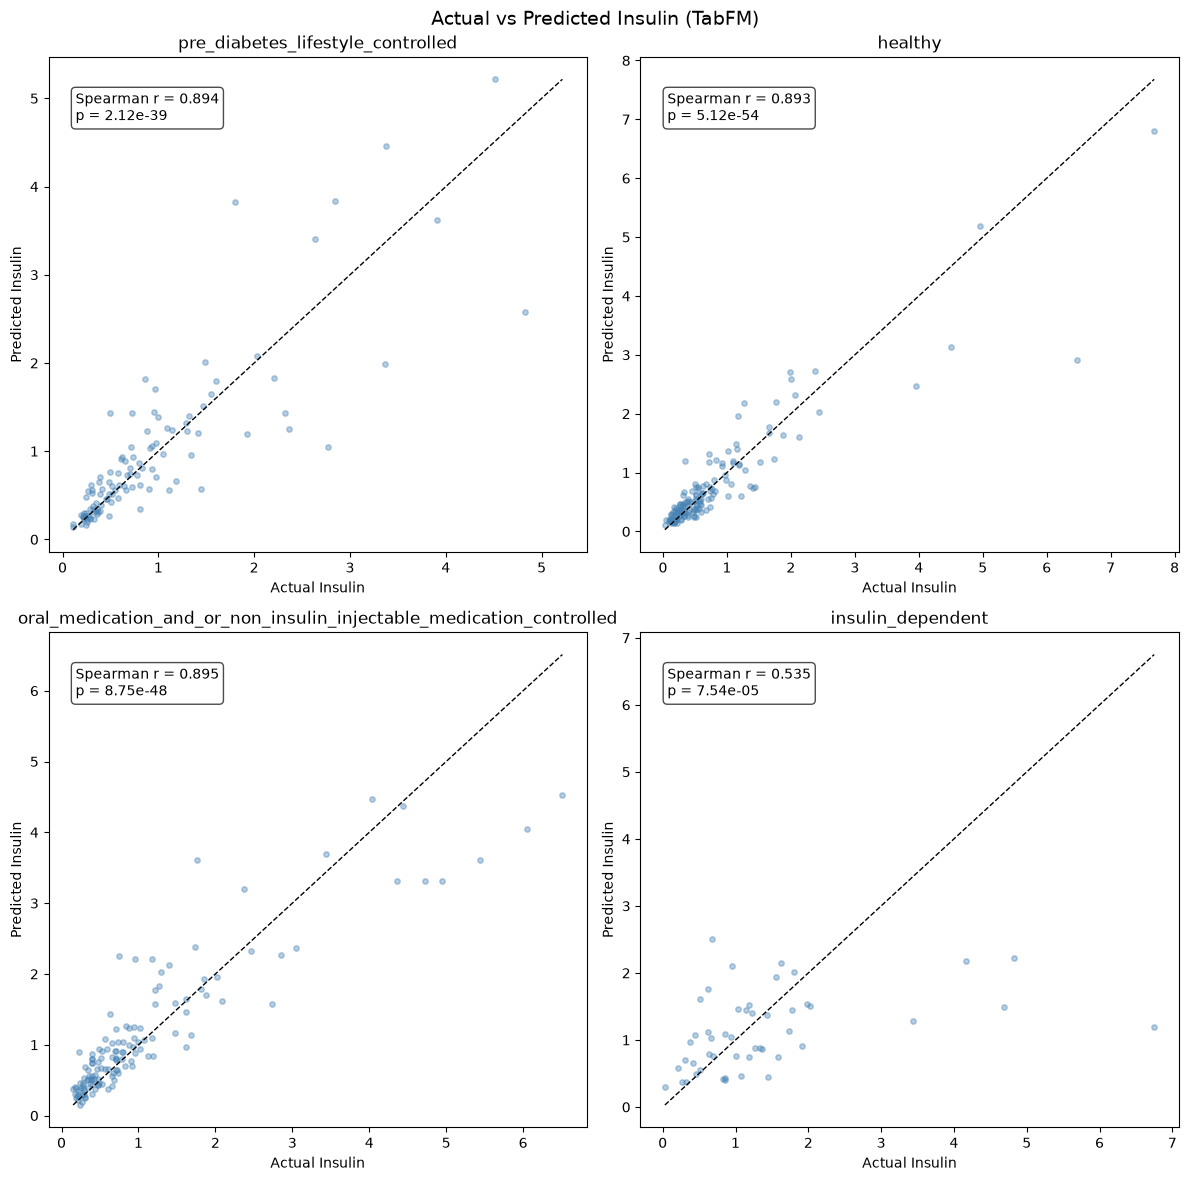

In [4]:
import matplotlib.pyplot as plt
from scipy import stats

groups = prediction_tabfm['study_group'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, group in zip(axes.flat, groups):
    group_df = prediction_tabfm[prediction_tabfm['study_group'] == group]
    actual = group_df['actual_insulin']
    preds = group_df['pred_insulin_tabfm']
    r, p = stats.spearmanr(actual, preds)

    ax.scatter(actual, preds, alpha=0.4, s=15, color='steelblue')
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)

    p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
    ax.text(0.05, 0.93, f'Spearman r = {r:.3f}\np = {p_str}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.set_xlabel('Actual Insulin')
    ax.set_ylabel('Predicted Insulin')
    ax.set_title(group)

for ax in axes.flat[len(groups):]:
    ax.axis('off')

fig.suptitle('Actual vs Predicted Insulin (TabFM)', fontsize=14)
plt.tight_layout()
plt.show()
